In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [2]:
emotion_dataset=load_dataset('dair-ai/emotion') #loading this dataset from hugging face
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
train_label

Column([0, 0, 3, 2, 3])

In [4]:
label_names=emotion_dataset['train'].features['label'].names

In [5]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
for i in train_label:
  print(label_names[i])

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [7]:
train_df=pd.DataFrame(
    {'text':train_text,
     'label':[label_names[i] for i in train_label]}
)

In [8]:
train_df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [9]:
df_test=pd.DataFrame(
    {
        'text':test_text,
        'label':[label_names[i] for i in test_label]
    }
)

##EDA

<Axes: xlabel='label', ylabel='count'>

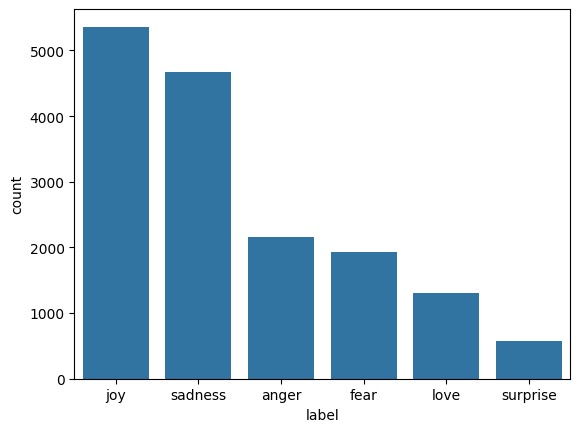

In [10]:
sns.countplot(x='label',data=train_df,order=train_df['label'].value_counts().index)
#class is being imbalanced here
# it is multi classification

In [11]:
from numpy.matrixlib import test
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<UNK>"
)

tokenizer.fit_on_texts(train_df["text"]) #yaha har word ko ek id milegi based on the frquency of the word
train_sequences=tokenizer.texts_to_sequences(train_df['text']) #yaha se ham sirf id leke ayege and words hatege
test_sequences=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences=pad_sequences(train_sequences,maxlen=50,padding='post',truncating='post')
padded_test_sequences=pad_sequences(test_sequences,maxlen=50,padding='post',truncating='post')
#abhi har sentence me different different length  hogi to har input ko same length ka banane ke liye we will use pad_sequence

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes=len(np.unique(train_labels))

print(f"Vocabulary size:{len(tokenizer.word_index)}")
print(f"Max length:{padded_train_sequences.shape[1]}")

Vocabulary size:15213
Max length:50


In [12]:
#computing the class weights becauyse we have unbalanced classes
from sklearn.utils import class_weight
class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict=dict(enumerate(class_weights))

In [24]:
#implementing early stopping

from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,# 3 epochs tak monitor karneka
    restore_best_weights=True # agar early stopping lagi to jis point pe lagti uske pehle wale epoch ke weights restore karke uspe training karneka
)

##phase 1 - Plain foundational models


In [27]:
from tensorflow.keras.layers import SimpleRNN,Dropout,Embedding,Dense,GRU,LSTM
from tensorflow.keras.models import Sequential

models=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True), #rnn ka hidden states 64 values dega
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])



In [28]:
models.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.1479 - loss: 1.8972 - val_accuracy: 0.1290 - val_loss: 1.8079
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.1602 - loss: 1.8046 - val_accuracy: 0.0610 - val_loss: 1.8093
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1676 - loss: 1.7845 - val_accuracy: 0.1245 - val_loss: 1.7948
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.1586 - loss: 1.7741 - val_accuracy: 0.2185 - val_loss: 1.7419
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.1297 - loss: 1.8602 - val_accuracy: 0.2575 - val_loss: 1.8087
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.1415 - loss: 1.8097 - val_accuracy: 0.1265 - val_loss: 1.7647
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1388 - loss: 1.8071 - val_accuracy: 0.1155 - val_loss: 1.7921


##lstm model (model2)

In [35]:
from tensorflow.keras.layers import SimpleRNN,Dropout,Embedding,Dense,GRU,LSTM
from tensorflow.keras.models import Sequential

lstm_models=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True), #rnn ka hidden states 64 values dega
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
lstm_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

lstm_models.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=10,
    batch_size=32,

    callbacks=[early_stopping]
)
lstm_loss,lstm_accuracy=lstm_models.evaluate(padded_test_sequences,test_labels)
print(f"Lstm loass:{lstm_loss}")
print(f"Lstm accuracy:{lstm_accuracy}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 146ms/step - accuracy: 0.3246 - loss: 1.5970 - val_accuracy: 0.3475 - val_loss: 1.5606
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 124ms/step - accuracy: 0.3293 - loss: 1.5840 - val_accuracy: 0.3475 - val_loss: 1.5593
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 135ms/step - accuracy: 0.3264 - loss: 1.5794 - val_accuracy: 0.3475 - val_loss: 1.5607
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 131ms/step - accuracy: 0.3279 - loss: 1.5854 - val_accuracy: 0.3475 - val_loss: 1.5427
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.3368 - loss: 1.4965 - val_accuracy: 0.3490 - val_loss: 1.4578
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.3599 - loss: 1.4403 - val_accuracy: 0.3705 - val_loss: 1.4072
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.3933 - loss: 1.3204 - val_accuracy: 0.4400 - val_loss: 1.2051
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 116ms/step - accuracy: 0.4663 - loss: 1

In [36]:
from tensorflow.keras.layers import SimpleRNN,Dropout,Embedding,Dense,GRU,LSTM
from tensorflow.keras.models import Sequential

gru_models=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    GRU(units=128,return_sequences=True), #rnn ka hidden states 64 values dega
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
gru_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

gru_models.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,

    callbacks=[early_stopping]
)
gru_loss,gru_accuracy=gru_models.evaluate(padded_test_sequences,test_labels)
print(f"Lstm loass:{gru_loss}")
print(f"Lstm accuracy:{gru_accuracy}")



Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 125ms/step - accuracy: 0.3196 - loss: 1.5987 - val_accuracy: 0.3475 - val_loss: 1.5677
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 102ms/step - accuracy: 0.3248 - loss: 1.5855 - val_accuracy: 0.3475 - val_loss: 1.5596
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.3291 - loss: 1.5830 - val_accuracy: 0.3475 - val_loss: 1.5601
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3475 - loss: 1.5677
Lstm loass:1.5677365064620972
Lstm accuracy:0.3474999964237213


##bidirectional GRU

In [37]:
from tensorflow.keras.layers import Bidirectional
BiGRU=Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),
    Bidirectional(GRU(units=128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
BiGRU.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

BiGRU.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,

    callbacks=[early_stopping]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 152s 291ms/step - accuracy: 0.6793 - loss: 0.8688 - val_accuracy: 0.9025 - val_loss: 0.2958
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - accuracy: 0.9320 - loss: 0.1902 - val_accuracy: 0.9180 - val_loss: 0.1858
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 186s 365ms/step - accuracy: 0.9542 - loss: 0.1200 - val_accuracy: 0.9225 - val_loss: 0.1912
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 288ms/step - accuracy: 0.9684 - loss: 0.0849 - val_accuracy: 0.9205 - val_loss: 0.2160
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 284ms/step - accuracy: 0.9746 - loss: 0.0689 - val_accuracy: 0.9275 - val_loss: 0.2459


In [39]:
bigru_loss,bigru_accuracy=BiGRU.evaluate(padded_test_sequences,test_labels)
print(f"gru loass:{bigru_loss}")
print(f"gru accuracy:{bigru_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9180 - loss: 0.1858
gru loass:0.18577617406845093
gru accuracy:0.9179999828338623


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step


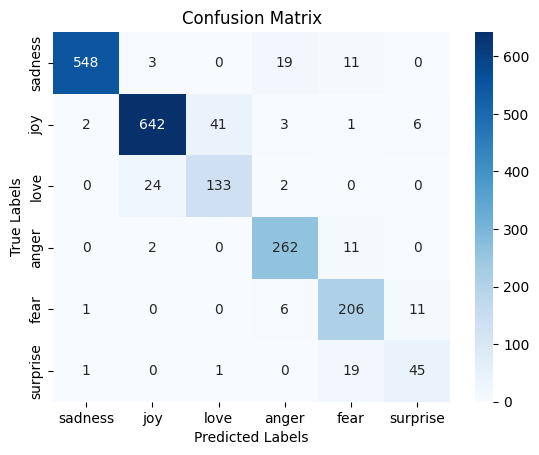

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
bigru_predictions=BiGRU.predict(padded_test_sequences)
bigru_predictions=np.argmax(bigru_predictions,axis=1)
cm=confusion_matrix(test_labels,bigru_predictions)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=label_names,yticklabels=label_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()



In [41]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: fear
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [44]:
import os
import pickle

model_dir='Artifacts'
os.makedirs(model_dir,exist_ok=True)
BiGRU.save(os.path.join(model_dir,'bigru_model.keras'))
with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer,file)